# Jev / GPT-6 Luna 실제 호출: 토큰·비용·시간

**2026-10-06, 합성 상품 4개 × 3회 × 2개 모델 = 실제 API 24회, 실패 0회.** 이 노트북은 저장된 실제 응답 기록을 분석합니다. 재실행해도 API를 호출하거나 비용을 발생시키지 않습니다.

고정된 HS 6자리 후보 3개 + 보류 옵션 2개, 동일한 상품·판단 지침으로 비교했습니다. LLM은 strict JSON 단일 choice, Jev는 Choice 확률도 반환합니다. GPT-6 Luna reasoning effort는 `low`입니다. 공급사 tokenizer와 입력 계약이 다르므로 토큰 수만으로 효율을 판단하지 않습니다.

시간은 한국 로컬 환경의 HTTP 요청부터 응답 파싱·검증까지이며, 공급사 모델 시간만의 측정이 아닙니다. 각 호출은 새 연결을 사용합니다. 첫 8회 응답을 확인한 뒤 나머지 16회를 진행했습니다. 이 보고서는 **요청 일지의 고유 실제 호출 24개**를 사용하므로, 노트북/CLI에서 과거 결과를 재표시한 로컬 캐시는 추가 관측에 포함되지 않습니다. 공급사 캐시 토큰은 별도 기록합니다.

비용은 API usage와 [TypeSafe 가격](https://docs.typesafe.ai/models), [OpenAI 가격](https://developers.openai.com/api/docs/models/gpt-6-luna)을 적용한 추정이며 청구서 확정 금액이 아닙니다. reasoning tokens는 output tokens에 포함되므로 비용에 두 번 더하지 않습니다. 미제공 usage 세부 항목은 미확인으로 유지합니다.

원자료: `private/jev-experiments/token-time-2026-10-06/requests.jsonl`; 이 옆 JSON은 인증정보·전체 요청 본문을 제외한 실제 호출 측정값입니다. 합성 표본 가설과의 일치는 관세 분류 정확도 증거가 아닙니다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown
roots = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in roots if (p/"jev-cost-time-2026-10-06.json").exists()), None)
if BASE is None:
    BASE = next((p/"notebooks" for p in roots if (p/"notebooks/jev-cost-time-2026-10-06.json").exists()), None)
if BASE is None:
    BASE = next((p/"product-catalog/notebooks" for p in roots if (p/"product-catalog/notebooks/jev-cost-time-2026-10-06.json").exists()), None)
assert BASE is not None
(BASE.parent/'private/jev-experiments/token-time-2026-10-06').mkdir(parents=True,exist_ok=True)
report = json.loads((BASE/"jev-cost-time-2026-10-06.json").read_text())
frame = pd.DataFrame(report["rows"])
assert len(frame)==24 and not frame.duplicated(["sample","provider","trial"]).any()
summary = frame.groupby("provider").agg(
    calls=("sample","size"), input_tokens=("input_tokens","sum"),
    output_tokens=("output_tokens","sum"),
    cached_input_tokens=("cached_input_tokens",lambda x:x.sum(min_count=1)),
    reasoning_output_tokens=("reasoning_output_tokens",lambda x:x.sum(min_count=1)),
    estimated_cost_usd=("estimated_cost_usd","sum"),
    p50_ms=("latency_ms","median"), p95_ms=("latency_ms",lambda x:x.quantile(.95)))
summary["mean_cost_usd_per_call"] = summary.estimated_cost_usd / summary.calls
display(summary.style.format({"estimated_cost_usd":"${:.8f}","mean_cost_usd_per_call":"${:.8f}","p50_ms":"{:.1f}","p95_ms":"{:.1f}"},na_rep="not reported"))
paired=frame.pivot(index=["sample","trial"],columns="provider",values="latency_ms")
paired["llm_over_jev"]=paired.llm / paired.jev
speed_ratio=summary.loc["llm","p50_ms"]/summary.loc["jev","p50_ms"]
cost_saving=1-summary.loc["jev","estimated_cost_usd"]/summary.loc["llm","estimated_cost_usd"]
display(Markdown(f"**관측: Jev 중앙 응답시간은 {speed_ratio:.2f}배 빠르고, 추정 총비용은 {cost_saving:.1%} 낮았습니다.** 총 추정 비용: ${summary.estimated_cost_usd.sum():.8f}. 동일 sample/trial의 지연 비율 중앙값: {paired.llm_over_jev.median():.2f}배. 검토 정답 표본 0개이므로 품질 우위는 미판정입니다."))
summary.to_csv(BASE.parent/"private/jev-experiments/token-time-2026-10-06/measured-summary.csv")

,calls,input_tokens,output_tokens,cached_input_tokens,reasoning_output_tokens,estimated_cost_usd,p50_ms,p95_ms,mean_cost_usd_per_call
provider,,,,,,,,,
jev,12,7065,900,not reported,not reported,$0.00029673,312.2,534.5,$0.00002473
llm,12,3540,201,0.000000,29.000000,$0.00045450,1593.0,2676.9,$0.00003788


**관측: Jev 중앙 응답시간은 5.10배 빠르고, 추정 총비용은 34.7% 낮았습니다.** 총 추정 비용: $0.00075123. 동일 sample/trial의 지연 비율 중앙값: 5.01배. 검토 정답 표본 0개이므로 품질 우위는 미판정입니다.

## 시간·비용 분포

각 공급사 12회. 박스는 25~75 백분위와 중앙값, 점은 실제 호출입니다. 비용 막대는 실제 usage에 기반한 추정 총액이며 두 공급사의 호출 수가 같습니다. 작은 표본의 p95는 탐색용입니다.

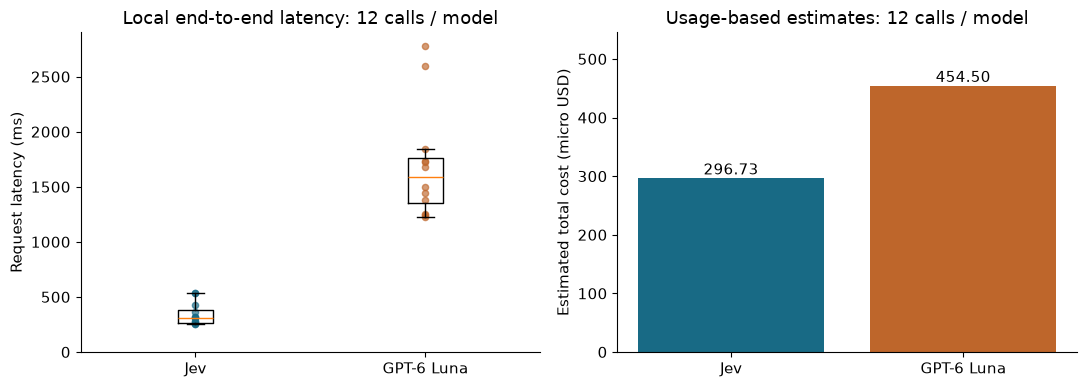

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11,"figure.figsize":(11,4),"axes.spines.top":False,"axes.spines.right":False})
fig, axes=plt.subplots(1,2,figsize=(11,4))
providers=["jev","llm"]
values=[frame.loc[frame.provider.eq(p),"latency_ms"].to_numpy() for p in providers]
axes[0].boxplot(values,tick_labels=["Jev","GPT-6 Luna"],showfliers=False)
for position, data in enumerate(values,1):
    axes[0].scatter([position]*len(data),data,s=20,alpha=.65,color=["#186A85","#BE662B"][position-1])
axes[0].set_ylim(bottom=0)
axes[0].set_ylabel("Request latency (ms)")
axes[0].set_title("Local end-to-end latency: 12 calls / model")
heights=[summary.loc[p,"estimated_cost_usd"]*1e6 for p in providers]
axes[1].bar(["Jev","GPT-6 Luna"],heights,color=["#186A85","#BE662B"])
axes[1].set_ylim(0,max(heights)*1.2)
axes[1].set_ylabel("Estimated total cost (micro USD)")
axes[1].set_title("Usage-based estimates: 12 calls / model")
for i,value in enumerate(heights):
    axes[1].text(i,value,f"{value:.2f}",ha="center",va="bottom")
fig.tight_layout()
fig.savefig(BASE.parent/"private/jev-experiments/token-time-2026-10-06/cost-time.png",dpi=180)
plt.show()

## 개별 관측과 해석

같은 상품의 반복 간 분산과 보류 응답을 확인합니다. 출력 토큰에는 내부 reasoning이 포함됩니다. Jev 출력은 확률을 포함하므로 출력 토큰 수 자체는 동일한 정보량의 비교가 아닙니다.

In [3]:
display(frame[["sample","provider","trial","input_tokens","output_tokens","reasoning_output_tokens","latency_ms","estimated_cost_usd","choice"]].round({"latency_ms":1,"estimated_cost_usd":8}))
display(paired.round(2))
print("Provisional label matches:", frame.groupby("provider").provisional_match.sum().to_dict())
print("Cached OpenAI input tokens:", frame.loc[frame.provider.eq("llm"),"cached_input_tokens"].sum())

,sample,provider,trial,input_tokens,output_tokens,reasoning_output_tokens,latency_ms,estimated_cost_usd,choice
0,playing-cards-ja,llm,0,307,14,0.0,2595.5,0.000038,950440
1,playing-cards-ja,jev,0,614,76,NaN,427.1,0.000026,950440
2,printed-book-en,llm,0,294,14,0.0,1727.2,0.000036,490199
3,printed-book-en,jev,0,583,76,NaN,533.6,0.000024,490199
4,whisky-ja,jev,0,582,76,NaN,281.1,0.000024,220830
5,whisky-ja,llm,0,292,29,13.0,1732.3,0.000044,220830
6,missing-function-ko,llm,0,287,14,0.0,1683.7,0.000036,needs_information
7,missing-function-ko,jev,0,576,72,NaN,257.4,0.000024,needs_information
8,playing-cards-ja,llm,1,307,14,0.0,1502.2,0.000038,950440
9,playing-cards-ja,jev,1,614,76,NaN,319.5,0.000026,950440


provider                      jev      llm  llm_over_jev
sample              trial                               
missing-function-ko 0      257.44  1683.72          6.54
                    1      535.68  1446.98          2.70
                    2      265.01  1384.16          5.22
playing-cards-ja    0      427.07  2595.53          6.08
                    1      319.52  1502.24          4.70
                    2      315.45  1842.84          5.84
printed-book-en     0      533.59  1727.17          3.24
                    1      255.53  1225.10          4.79
                    2      268.19  2776.30         10.35
whisky-ja           0      281.11  1732.33          6.16
                    1      365.87  1251.98          3.42
                    2      308.88  1245.78          4.03

Provisional label matches: {'jev': 12, 'llm': 12}
Cached OpenAI input tokens: 0.0


## 적용 판단의 범위

이 호출 조건에서 비용·시간은 Jev 쪽이 유리했습니다. 다만 상품 4개·후보 5개만 비교한 결과이며, 장문 입력·96개 HS 장 선택·전체 2→4→6 파이프라인의 실행시간이나 정확도로 일반화할 수 없습니다. GPT-6 Luna `low`와의 비교이고 reasoning `none`이나 다른 LLM은 측정하지 않았습니다.

다음 실험은 실제 판매글과 더 큰 후보 목록을 사용하되, 이번 실행과 조건을 구분해야 합니다. 품질·보류 성능은 근거를 검토한 정답 표본으로 평가합니다. HS 후보를 확정 한국 HSK나 세율로 승격하지 않습니다.